In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Generate synthetic data
def generate_data(n=30):
    np.random.seed(42)  # for reproducibility
    sizes = np.random.uniform(50, 300, n)
    prices = sizes * (np.random.uniform(1.5, 3, n)) + np.random.normal(0, 50, n)
    return sizes, prices

# Generate the data
x, y = generate_data()

# Print the data
print("Dataset:")
for size, price in zip(x, y):
    print(f"Size: {size:.2f} m², Price: ${price:.2f}k")

Dataset:
Size: 143.64 m², Price: $272.42k
Size: 287.68 m², Price: $469.11k
Size: 233.00 m², Price: $349.20k
Size: 199.66 m², Price: $636.54k
Size: 89.00 m², Price: $279.61k
Size: 89.00 m², Price: $153.27k
Size: 64.52 m², Price: $142.47k
Size: 266.54 m², Price: $419.61k
Size: 200.28 m², Price: $472.13k
Size: 227.02 m², Price: $520.99k
Size: 55.15 m², Price: $144.36k
Size: 292.48 m², Price: $702.52k
Size: 258.11 m², Price: $358.52k
Size: 103.08 m², Price: $279.77k
Size: 95.46 m², Price: $196.80k
Size: 95.85 m², Price: $287.81k
Size: 126.06 m², Price: $224.07k
Size: 181.19 m², Price: $403.85k
Size: 157.99 m², Price: $311.22k
Size: 122.81 m², Price: $158.45k
Size: 202.96 m², Price: $640.26k
Size: 84.87 m², Price: $293.80k
Size: 123.04 m², Price: $354.34k
Size: 141.59 m², Price: $452.61k
Size: 164.02 m², Price: $411.21k
Size: 246.29 m², Price: $677.76k
Size: 99.92 m², Price: $181.21k
Size: 178.56 m², Price: $397.23k
Size: 198.10 m², Price: $308.80k
Size: 61.61 m², Price: $200.72k


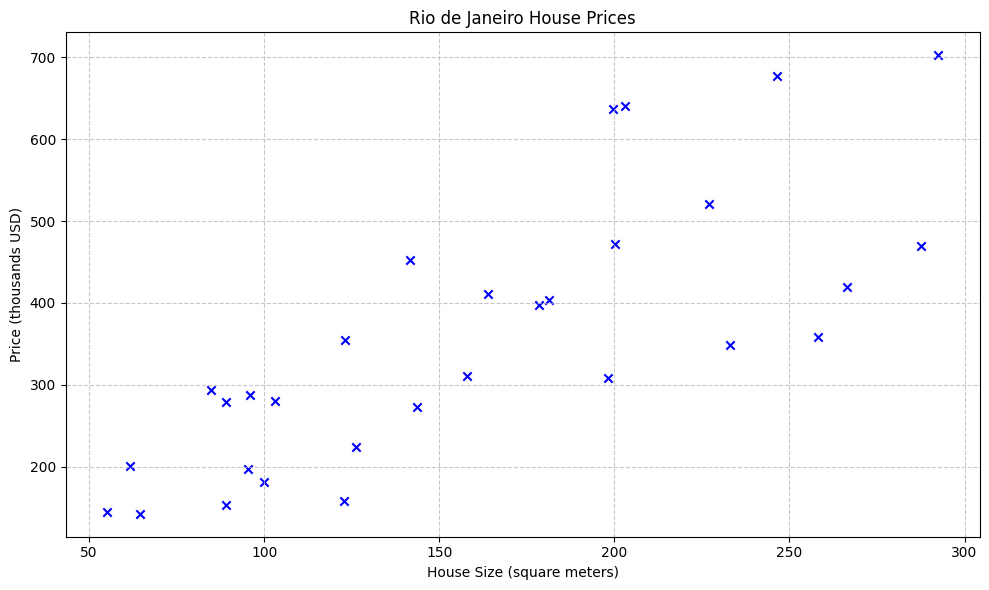

In [ ]:
# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, marker='x', color='blue')
plt.xlabel('House Size (square meters)')
plt.ylabel('Price (thousands USD)')
plt.title('Rio de Janeiro House Prices')

# Add a trend line
# z = np.polyfit(sizes, prices, 1)
# p = np.poly1d(z)
# plt.plot(sizes, p(sizes), "r--", alpha=0.8)

# Customize the plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
D = np.array([[1,1], [2,2], [3,3]])
x_ex = D[:,0]
y_ex = D[:,1]
m = D.shape[0]

# Function to compute the mean squared error of a linear model in D
def model(w, x, b=0):
    return np.dot(w, x) + b

def loss(y, y_hat):
    loss = (1/(2*m)) * np.sum((y_hat - y) ** 2)
    return loss

print(loss(y_ex, model(1, x_ex)))
print(loss(y_ex, model(0.5, x_ex)))
print(loss(y_ex, model(0, x_ex)))
print(loss(y_ex, model(-0.5, x_ex)))

0.0
0.5833333333333333
2.333333333333333
5.25


In [ ]:
# Create a grid of w and b values
w_range = np.arange(-10, 10, 1)
b_range = np.arange(-1000, 1000, 100)
W, B = np.meshgrid(w_range, b_range)

# Calculate the loss for each combination of w and b
Z = np.array([loss(y, model(w, x, b)) for w, b in zip(W.flatten(), B.flatten())]).reshape(W.shape)

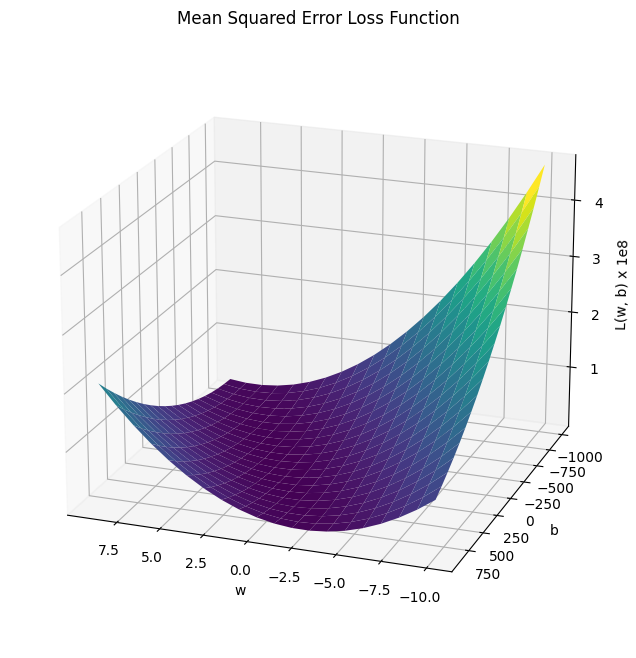

In [ ]:
# Create the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Rotate the plot
ax.view_init(elev=20, azim=110)

# Plot the surface
ax.plot_surface(W, B, Z, cmap='viridis')

# Set labels
ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_zlabel('L(w, b) x 1e8')

# Set title
ax.set_title('Mean Squared Error Loss Function')

# Show the plot
plt.show()

In [ ]:
# Visualize lines with different configurations of w and b
w_test = [1.8, 2.5, 3.0]
b_test = [50, 100, 0]
colors = ['blue', 'orange', 'green']

Losses of the three models:
Model with w = 1.8, b = 50, c = blue, Loss = 51591.45
Model with w = 2.5, b = 100, c = orange, Loss = 163636.46
Model with w = 3.0, b = 0, c = green, Loss = 160300.76


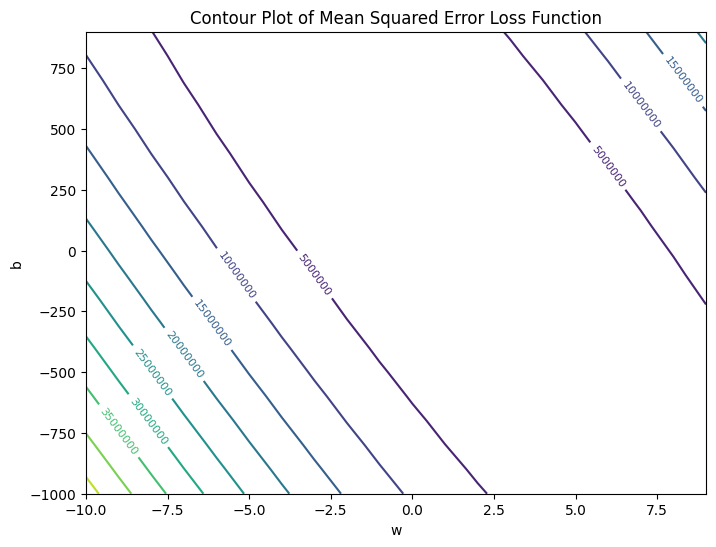

In [ ]:
# Create the contour plot
plt.figure(figsize=(8, 6))
contours = plt.contour(W, B, Z, levels=10, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)

# Compute and show the losses of the three models
loss_test = [loss(y, model(w, x, b)) for w, b in zip(w_test, b_test)]

print("Losses of the three models:")
for w, b, l, c in zip(w_test, b_test, loss_test, colors):
    print(f"Model with w = {w}, b = {b}, c = {c}, Loss = {l:.2f}")
    # plt.plot(w, b, 'x', color=c, markersize=10)

# Set labels
plt.xlabel('w')
plt.ylabel('b')
plt.title('Contour Plot of Mean Squared Error Loss Function')

# Show the plot
plt.show()

Model with w = 1.8, b = 50, c = blue, Loss = 51591.45
Model with w = 2.5, b = 100, c = orange, Loss = 163636.46
Model with w = 3.0, b = 0, c = green, Loss = 160300.76


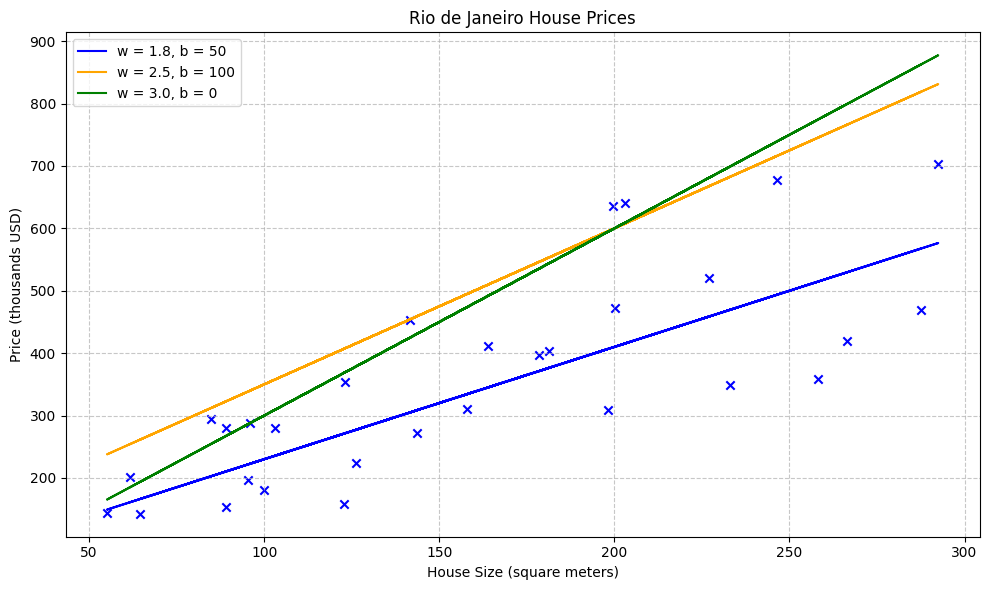

In [ ]:
# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, marker='x', color='blue')
plt.xlabel('House Size (square meters)')
plt.ylabel('Price (thousands USD)')
plt.title('Rio de Janeiro House Prices')

# Visualize lines with different configurations of w and b
for w, b, c in zip(w_test, b_test, colors):
    plt.plot(x, model(w, x, b), label=f'w = {w}, b = {b}', color=c, alpha=1)

# Customize the plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend()

# Compute and show the losses of the three models
loss_values = [loss(y, model(w, x, b)) for w, b in zip(w_test, b_test)]

for w, b, c, l in zip(w_test, b_test, colors, loss_values):
    print(f"Model with w = {w}, b = {b}, c = {c}, Loss = {l:.2f}")

# Show the plot
plt.show()

In [ ]:
def f(x):
  return x**2

def derivative(x):
  return 2*x

def approx_derivative(f, x, h=0.000000001):
  return (f(x+h) - f(x))/h

da_exact = derivative(x=3)
da_approx = approx_derivative(f,x=3)
print(da_exact, da_approx)

6 6.000000496442226


In [ ]:
def plot_model(x, y, w, b):
  # Restart plot
  plt.figure(figsize=(10, 6))
  plt.clf()

  # Plot data
  plt.scatter(x, y, marker='x', color='blue')
  plt.xlabel('House Size (square meters)')
  plt.ylabel('Price (thousands USD)')
  plt.title('Rio de Janeiro House Prices')

  # Plot model with paramters w and b
  y_pred = model(x, w, b)

  plt.plot(x, y_pred, label=f'w = {w}, b = {b}', alpha=1)
  plt.legend()
  plt.show()

def plot_loss(x, w, b):
  # Create a grid of w and b values
  w_range = np.linspace(-300, 300, 50)
  b_range = np.linspace(-1000, 1000, 50)
  W, B = np.meshgrid(w_range, b_range)

  # Calculate the loss for each combination of w and b
  Z = np.array([loss(y, model(x, w, b)) for w, b in zip(W.flatten(), B.flatten())]).reshape(W.shape)

  # Create the contour plot
  plt.figure(figsize=(8, 6))
  contours = plt.contour(W, B, Z, levels=30, cmap='viridis')
  plt.clabel(contours, inline=True, fontsize=8)

  plt.plot(w, b, 'x', color=c, markersize=10)

  # Set labels
  plt.xlabel('w')
  plt.ylabel('b')
  plt.title('Contour Plot of Mean Squared Error Loss Function')

  # Show the plot
  plt.show()

# Hypothesis
def model(x, w, b):
  return np.dot(w,x) + b

def loss(y, y_hat):
  loss = (1/(2*m)) * np.sum((y_hat - y) ** 2)
  return loss

def optimize(x, y, n_iterations=3, alpha=0.001):
  # Init parameters
  w,b = 0, 0

  for i in range(n_iterations):
    y_pred = model(x, w, b)
    loss_value = loss(y, y_pred)

    y_hat = model(x, w, b)

    dw = (1 / m) * np.sum((y_hat - y) * x)
    db = (1 / m) * np.sum(y_hat - y)

    w = w - alpha * dw
    b = b - alpha * db

    if i % 500 == 0:
      print(f"Iteration {i+1}: Loss = {loss_value}")
      # plot_model(x, y, w, b)
      plot_loss(x,w,b)

  return w,b

(30,)
(30,)
Number of examples 30
Iteration 1: Loss = 76220.0353596681


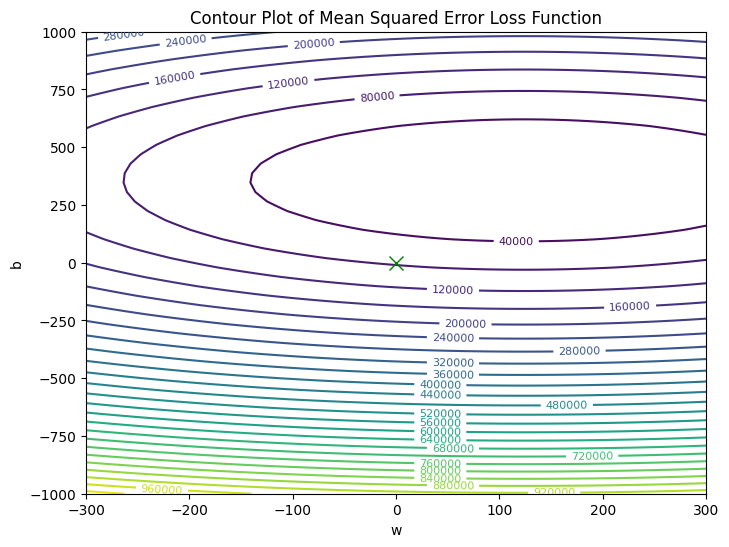

Iteration 501: Loss = 31169.295524268346


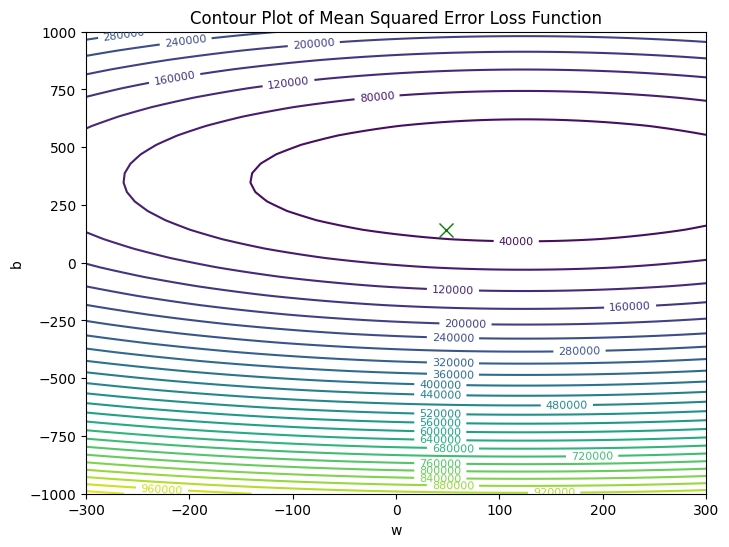

Iteration 1001: Loss = 14604.344604244834


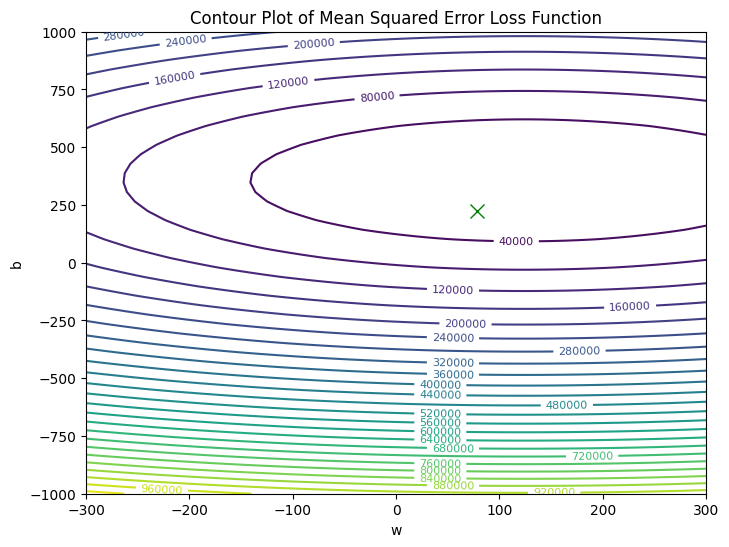

Iteration 1501: Loss = 8513.48793939663


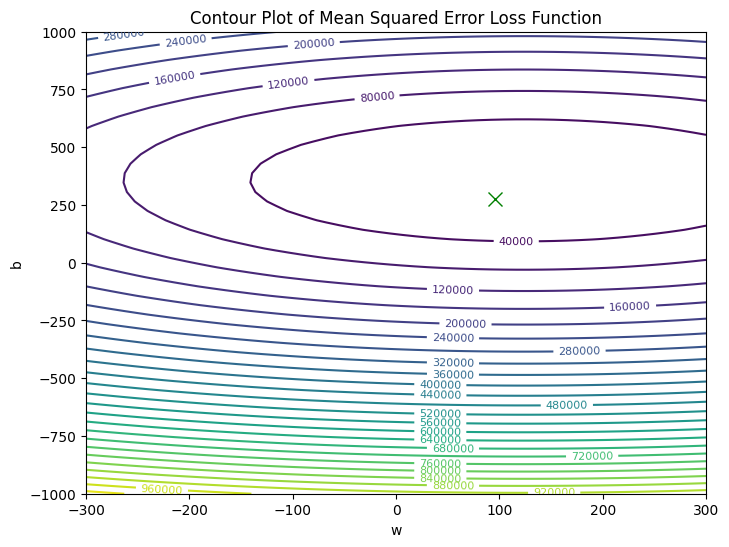

Iteration 2001: Loss = 6273.907810796187


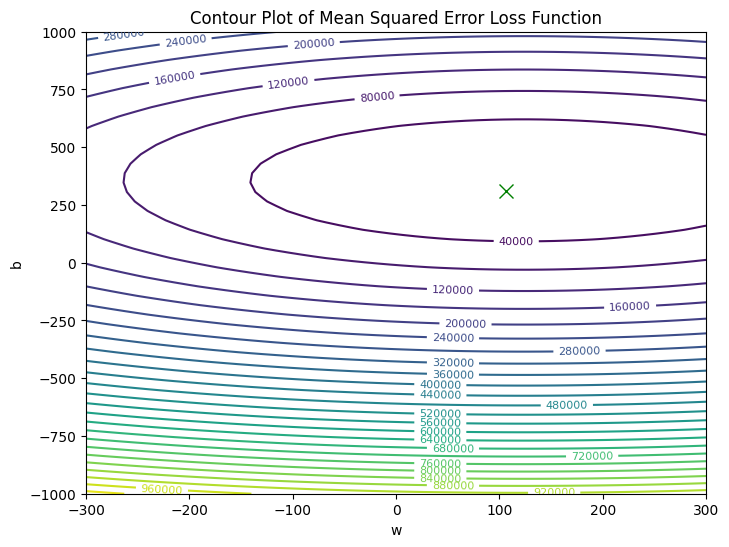

Iteration 2501: Loss = 5450.424444101868


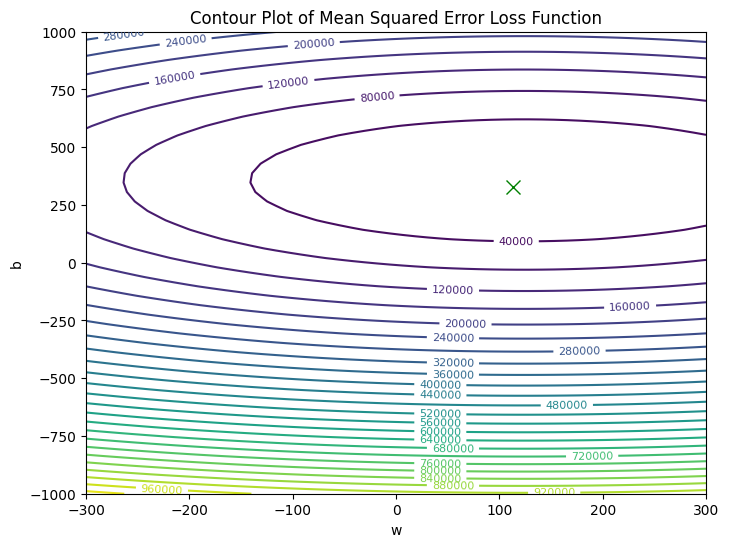

Iteration 3001: Loss = 5147.633377793368


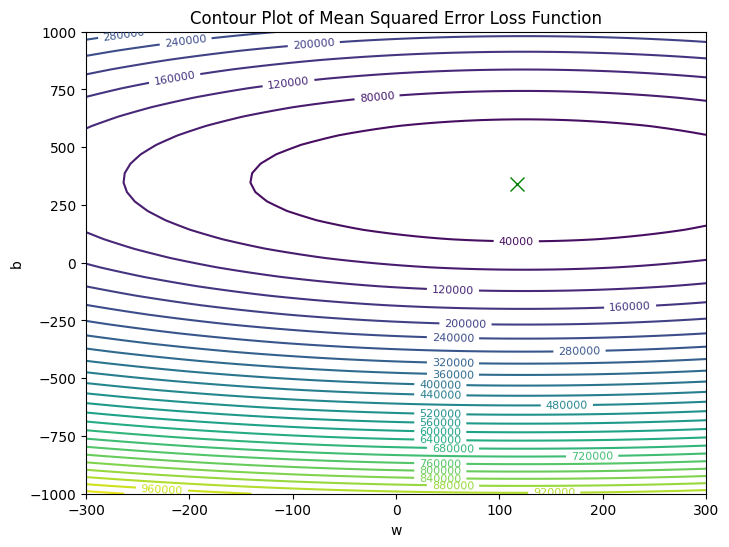

Iteration 3501: Loss = 5036.2984880502145


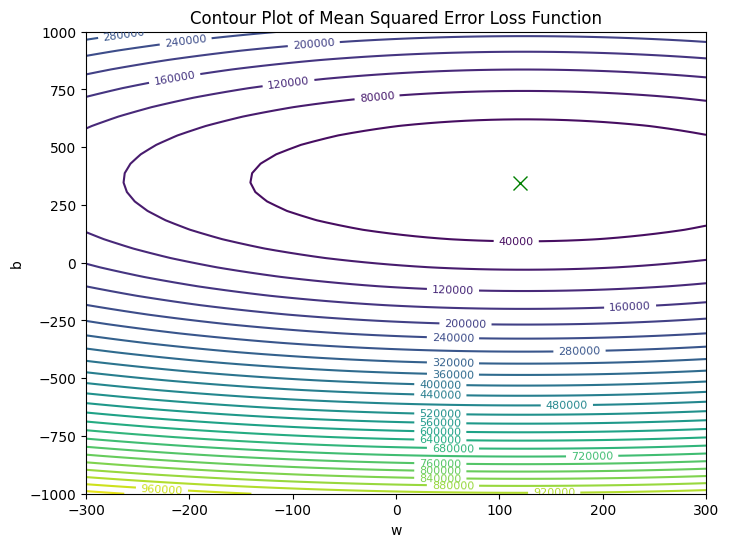

Iteration 4001: Loss = 4995.36115847427


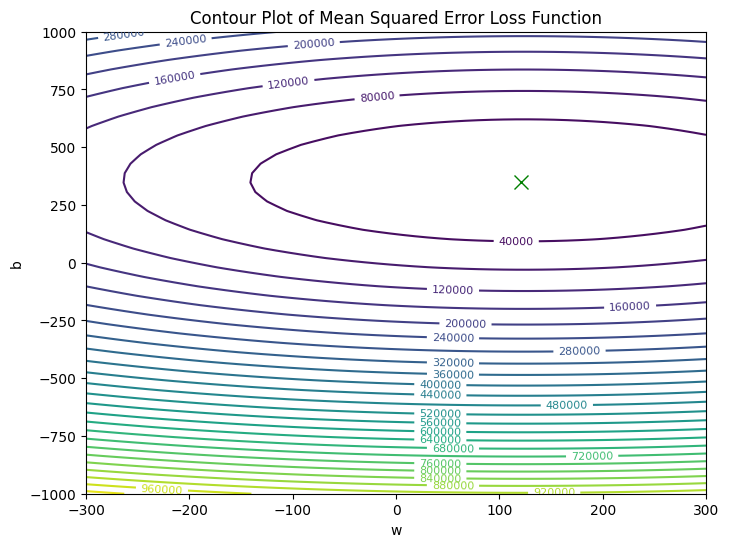

Iteration 4501: Loss = 4980.30868968686


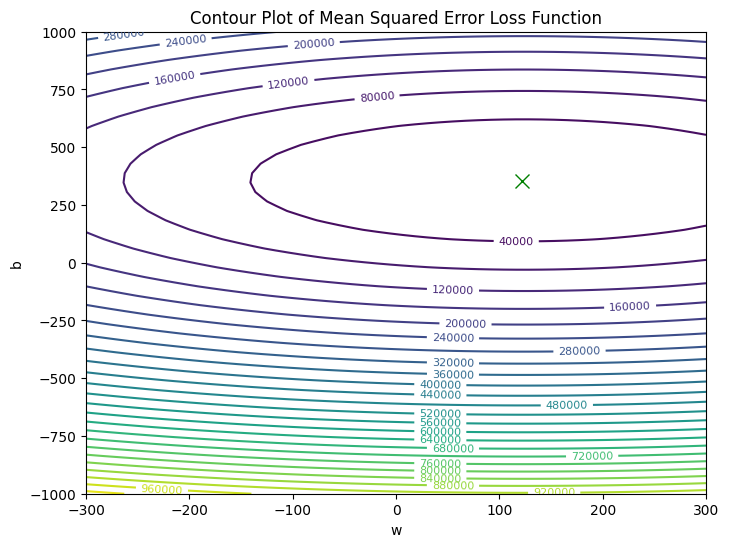

In [ ]:
# Normalize the data
x_norm = (x - np.mean(x)) / np.std(x)
print(x_norm.shape)
print(y.shape)

m = x.shape[0]
print("Number of examples", m)

y_hat = model(x_norm, w, b)
w,b = optimize(x_norm, y, n_iterations=5000)